In [4]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import torch

from tqdm import tqdm

# Multiclass Trade Classifier (LSTM) — Training Template

Trains a 3-class sequence classifier to identify high-probability trade entries:
**SELL (class 0)**, **FLAT (class 1)**, or **BUY (class 2)** — using causal triple-barrier labeling.

**To use this notebook as a template:**
1. Set all experiment parameters in the **Configuration** cell below
2. Adjust label params, model architecture, and loss weights as needed
3. Run all cells sequentially — the trained model pack is saved to `Engine/Model Packs/`

| Component | Description |
|---|---|
| Labels | Causal triple-barrier with Hi/Lo trend filter → SELL=0 / FLAT=1 / BUY=2 |
| Features | OHLCV + ATR + regime indicators (parity with live engine) |
| Model | `LSTMAttentionSEClassifier` with `num_classes=3` |
| Loss | `TradeProfitabilityLoss` — focal CE + soft expected-profit optimisation |

In [5]:
DS_NAME      = '../data/US500_1minute.csv'  # Path to OHLCV CSV
TEST_START   = '2026-01-01'                 # Date to split train / validation
N_ROWS       = 1_000_000                         # Max rows to load (None = all)

SEQ_LEN      = 256    # 256 x 1-min ~ 4 hours lookback window
BATCH_SIZE   = 512    # Mini-batch size

NUM_EPOCHS   = 10
BASE_LR      = 1e-4
WEIGHT_DECAY = 1e-3

HOLDOUT_SIZE    = 0.10                # Fraction of training data used as internal holdout
ROLLOVER_WINDOW = ('21:30', '22:00')  # Broker rollover window: targets zeroed out
TRADING_HOURS   = None                # Set e.g. ('07:00', '20:00') to gate by session

COMMISSION   = 0.10   # Fraction of trade outcome deducted as broker fee

MODEL_VERSION = 'v1'  # Version tag appended to saved model pack filename

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load Dataset

In [6]:
def load_ohlcv(ds_name, n_rows=None):
    df = pd.read_csv(ds_name)
    if n_rows is not None:
        df = df.tail(n_rows)
    df = df.sort_values('Time').reset_index(drop=True)
    return df

def train_val_split(df, test_date=None):
    if test_date is None:
        return df, None
    test_start = df[df['Time'] > test_date].index[0]
    df_test  = df.iloc[test_start:, :].copy().reset_index(drop=True)
    df_train = df[df['Time'] < test_date].reset_index(drop=True)
    return df_train, df_test

df = load_ohlcv(DS_NAME, N_ROWS)
df, df_test = train_val_split(df, TEST_START)
print(f"Train: {len(df):,} rows | Val: {len(df_test):,} rows")

Train: 947,949 rows | Val: 52,051 rows


## Label Configuration

Tune the triple-barrier parameters to control entry selectivity.
Higher `tp_mult`/`sl_mult` ratio gives fewer but better-quality entries.
Increase `trend_pullback_thresh` to require stronger trend confirmation.

In [7]:
from Learn.labels import causal_triple_barrier_hilow_trend_labeler, calculate_trade_outcomes_all_candles

regime_params = {
    "ma_period": 15,
    "slope_smoothness": 30,
    "regime_min_duration": 0,
    "atr_window": 60,
    "atr_lookback": 1440,
    "atr_percentile": 0.0,
    "slope_threshold": 0.02
}

label_params = {
    "z_window": 14,
    "z_thresh": 1,
    "z_limit": 5,
    "atr_window": 14,
    "tp_mult": 2.5,
    "sl_mult": 2.5,
    "max_horizon": 90,
    "trend_pullback_thresh": 1.0,
    "regime_params": regime_params,
    "skip_range": True
}

## Generate Trade Entry Labels

Uses `causal_triple_barrier_hilow_trend_labeler` with fully causal parameters.
Winning bars where a trade succeeds are mapped to:
- **SELL (0)** — for `target == -1` wins
- **BUY  (2)** — for `target == +1` wins
- **FLAT (1)** — all other bars, plus the broker rollover window

In [8]:
for name, d in [('df', df), ('df_test', df_test)]:
    signals = causal_triple_barrier_hilow_trend_labeler(d, **label_params).rename(columns={'side': 'target'})
    winning  = signals[signals['label'] == 1]

    # Multiclass targets: 0 = SELL, 1 = FLAT, 2 = BUY
    d['mc_target'] = 1  # default: FLAT
    d.loc[winning[winning['target'] ==  1].index, 'mc_target'] = 2  # BUY
    d.loc[winning[winning['target'] == -1].index, 'mc_target'] = 0  # SELL

    # Zero-out targets during rollover window
    if not pd.api.types.is_datetime64_any_dtype(d['Time']):
        d['Time'] = pd.to_datetime(d['Time'])
    rollover = (
        (d['Time'].dt.time >= pd.to_datetime(ROLLOVER_WINDOW[0]).time()) &
        (d['Time'].dt.time <  pd.to_datetime(ROLLOVER_WINDOW[1]).time())
    )
    d.loc[rollover, 'mc_target'] = 1  # force FLAT during rollover
    print(f"{name}: {rollover.sum()} rollover rows zeroed | mc_target dist:")
    print(d['mc_target'].value_counts().sort_index().rename({0:'SELL',1:'FLAT',2:'BUY'}), "\n")

df_val = df_test.copy()

df: 5301 rollover rows zeroed | mc_target dist:
mc_target
SELL     20427
FLAT    906472
BUY      21050
Name: count, dtype: int64 

df_test: 978 rollover rows zeroed | mc_target dist:
mc_target
SELL     1176
FLAT    49556
BUY      1319
Name: count, dtype: int64 



## Calculate Trade Outcomes

Computes per-bar TP/SL/timeout outcomes for every candle (both BUY and SELL directions).
Both outcome columns are stored in `sell_y` / `buy_y` — column names already excluded from
the feature matrix by `preprocess_ohlcv`.  Winning outcomes are doubled to increase the
reward signal for correct predictions.

In [9]:
outcome_params = {k: v for k, v in label_params.items()
                  if k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}
outcome_params['max_horizon'] = 1000

for name, d in [('df', df), ('df_val', df_val)]:
    outcomes = calculate_trade_outcomes_all_candles(d, **outcome_params)

    # Double TP rewards to strengthen the profit signal
    for col in ['buy_outcome', 'sell_outcome']:
        outcomes[col] = outcomes[col].clip(upper=None).where(outcomes[col] <= 0, outcomes[col] * 2)

    # Store in columns that preprocess_ohlcv already excludes from features
    d['sell_y'] = outcomes['sell_outcome'].fillna(0.0)
    d['buy_y']  = outcomes['buy_outcome'].fillna(0.0)

    tp  = (outcomes['buy_outcome']  == 2).sum()
    sl  = (outcomes['buy_outcome']  == -1).sum()
    to  = (outcomes['buy_outcome']  == 0).sum()
    stp = (outcomes['sell_outcome'] == 2).sum()
    ssl = (outcomes['sell_outcome'] == -1).sum()
    sto = (outcomes['sell_outcome'] == 0).sum()
    print(f"{name} outcomes | Buy  TP:{tp} TO:{to} SL:{sl} | Sell TP:{stp} TO:{sto} SL:{ssl}")

print('\nTrain label dist (%):\n',
      df['mc_target'].value_counts(normalize=True).sort_index()
        .rename({0:'SELL', 1:'FLAT', 2:'BUY'}).mul(100).round(1))

df outcomes | Buy  TP:398039 TO:0 SL:549868 | Sell TP:382162 TO:1 SL:565748
df_val outcomes | Buy  TP:20874 TO:0 SL:31154 | Sell TP:21470 TO:0 SL:30558

Train label dist (%):
 mc_target
SELL     2.2
FLAT    95.6
BUY      2.2
Name: proportion, dtype: float64


## Feature Engineering

Adds technical indicators to the OHLCV data.
Features are computed in-parity with the live trading engine.

In [10]:
from Learn.features import add_selected_features

df     = add_selected_features(df,     regime_params=regime_params)
df_val = add_selected_features(df_val, regime_params=regime_params)

## Preprocessing & Scaling

The scaler is **fit on the training split only** and then applied to the validation split.

The `sell_y` / `buy_y` columns carry trade outcomes through the preprocessing pipeline
(they are excluded from the feature matrix by `preprocess_ohlcv`) and are then stacked
into a `(N, 2)` array — `[:, 0]` = sell outcome, `[:, 1]` = buy outcome — passed directly
to `TradeProfitabilityLoss` during training.

In [11]:
from Learn.preprocess import preprocess_ohlcv

preprocess_ohlcv_args = {
    'target_col':      'mc_target',
    'outcomes_col':    None,   # outcomes extracted from proc_df via sell_y / buy_y
    'shift':           0,
    'onehot_prefixes': ['OH_'],
    'price_prefixes':  ['PR_'],
}

split_idx = int(len(df) * (1 - HOLDOUT_SIZE))

X_train, y_train, scaler, features, _, proc_df_train = preprocess_ohlcv(
    df.iloc[:split_idx].copy(), **preprocess_ohlcv_args, scaler=None, return_df=True)

X_test, y_test, _, _, _, proc_df_test = preprocess_ohlcv(
    df.iloc[split_idx:].copy(), **preprocess_ohlcv_args, scaler=scaler, return_df=True)

X_train = np.ascontiguousarray(X_train)
X_test  = np.ascontiguousarray(X_test)

y_train = [int(x) for x in y_train]
y_test  = [int(x) for x in y_test]

# Extract NaN-aligned outcomes from proc_df (sell_y / buy_y survive dropna since they were fillna'd)
outcomes_train_2d = np.stack([proc_df_train['sell_y'].values,
                               proc_df_train['buy_y'].values], axis=1).astype(float)
outcomes_test_2d  = np.stack([proc_df_test['sell_y'].values,
                               proc_df_test['buy_y'].values], axis=1).astype(float)

train_idx = list(range(len(X_train)))
test_idx  = list(range(len(X_test)))

# Anchor-time session gating
def _session_seq_indices(times, seq_len, trading_hours):
    if trading_hours is None:
        return list(range(len(times) - seq_len))
    t_start = pd.to_datetime(trading_hours[0]).time()
    t_end   = pd.to_datetime(trading_hours[1]).time()
    return [
        i for i in range(len(times) - seq_len)
        if t_start <= pd.Timestamp(times[i + seq_len - 1]).time() < t_end
    ]

train_times = proc_df_train['Time'].to_numpy()
test_times  = proc_df_test['Time'].to_numpy()

train_seq_idx = _session_seq_indices(train_times, SEQ_LEN, TRADING_HOURS)
test_seq_idx  = _session_seq_indices(test_times,  SEQ_LEN, TRADING_HOURS)

n_train_all = len(X_train) - SEQ_LEN
n_test_all  = len(X_test)  - SEQ_LEN
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Session-gated seqs -- Train: {len(train_seq_idx):,}/{n_train_all:,} "
      f"| Test: {len(test_seq_idx):,}/{n_test_all:,}  (TRADING_HOURS={TRADING_HOURS})")

Train: (852361, 89) | Test: (94795, 89)
Session-gated seqs -- Train: 852,105/852,105 | Test: 94,539/94,539  (TRADING_HOURS=None)


## Data Loaders

Each sample includes a `(2,)` outcome tensor `[sell_outcome, buy_outcome]` which is
passed directly to `TradeProfitabilityLoss` to optimise for expected profit.

In [12]:
from Learn.Loaders import SequenceDataset
from torch.utils.data import DataLoader

train_ds = SequenceDataset(X_train, y_train, seq_len=SEQ_LEN, df_idx=train_idx,
                           custom_targets=None, trade_outcomes=outcomes_train_2d,
                           seq_idx_filter=train_seq_idx)
val_ds   = SequenceDataset(X_test,  y_test,  seq_len=SEQ_LEN, df_idx=test_idx,
                           custom_targets=None, trade_outcomes=outcomes_test_2d,
                           seq_idx_filter=test_seq_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=0)

print(f"DataLoaders ready -- train batches: {len(train_loader):,} | val batches: {len(val_loader):,}")

DataLoaders ready -- train batches: 1,665 | val batches: 185


## Model

`LSTMAttentionSEClassifier` with `num_classes=3` — same architecture as the binary models
but with a 3-head output (SELL / FLAT / BUY).

The log-prior bias initialisation uses all three class frequencies, which prevents
the model spending early epochs learning the class imbalance from scratch.

| Param | Description |
|---|---|
| `hidden_dim` | LSTM hidden state size (output dim = `hidden_dim x 2` for bidirectional) |
| `num_layers` | Number of stacked BiLSTM layers |
| `attn_heads` | Number of heads for MHA pooling — must divide `hidden_dim x 2` evenly |
| `bias_init` | 3-element log-prior bias `[log(p_sell), log(p_flat), log(p_buy)]` |

In [13]:
from Learn.Models import LSTMAttentionSEClassifier

# 3-class log-prior bias: stabilises early training on imbalanced labels
y_train_arr = np.array(y_train)
p_sell = (y_train_arr == 0).mean()
p_flat = (y_train_arr == 1).mean()
p_buy  = (y_train_arr == 2).mean()
bias_init = [math.log(p_sell + 1e-8), math.log(p_flat + 1e-8), math.log(p_buy + 1e-8)]
print(f"Class rates -- SELL: {p_sell:.4f}  FLAT: {p_flat:.4f}  BUY: {p_buy:.4f}")
print(f"bias_init: {[round(b, 3) for b in bias_init]}")

model_params = {
    'input_dim':          X_train.shape[1],
    'hidden_dim':         192,   # embed dim = 384
    'num_layers':         2,
    'num_classes':        3,     # SELL / FLAT / BUY
    'bidirectional':      True,
    'dropout':            0.15,
    'dropout_out':        0.30,
    'attn_heads':         8,     # 384 % 8 == 0
    'attn_dropout':       0.05,
    'use_learned_query':  True,
    'bias_init':          bias_init,
}

model = LSTMAttentionSEClassifier(**model_params).to(device)
MODEL_TYPE = 'LSTM_Multiclass'
print(f"Model: {MODEL_TYPE} | Params: {sum(p.numel() for p in model.parameters()):,}")


Class rates -- SELL: 0.0215  FLAT: 0.9564  BUY: 0.0221
bias_init: [-3.842, -0.045, -3.81]
Model: LSTM_Multiclass | Params: 2,026,803


### Class Weights & Loss Function

`TradeProfitabilityLoss` combines:
- Focal cross-entropy (handles class imbalance)
- Soft precision/recall optimisation for trade classes {0, 2}
- Soft expected-profit term: `sum(p_sell * sell_outcome + p_buy * buy_outcome)` per batch

This gives the optimiser a direct, fully-differentiable profit signal on every training step.

In [14]:
from Learn.Loss import TradeProfitabilityLoss

# Inverse-frequency class weights with moderate strengthening for minority trade classes.
# exponent=0.6 is slightly stronger than sqrt while avoiding extreme FLAT down-weighting.
counts = np.maximum(np.bincount(y_train, minlength=3), 1)
raw_weights = (len(y_train) / (len(counts) * counts)).astype(float)
weights = np.power(raw_weights, 0.6)                  # tuned for SELL/BUY recovery
weights = weights / weights.mean()                    # re-scale so mean weight = 1
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights (SELL, FLAT, BUY):', class_weights.cpu().numpy().round(3))
print('Train distribution:\n',
      pd.Series(y_train).value_counts(normalize=True).sort_index()
        .rename({0:'SELL', 1:'FLAT', 2:'BUY'}).mul(100).round(1))

optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

loss_params = {
    'alpha':           class_weights,
    'gamma':           1.5,
    'trade_classes':   (0, 2),
    'pr_weight':       7.0,
    'rec_weight':      3.5,
    'f1_weight':       0.5,
    'profit_weight':   0.0,
    'loss_penalty':    3.0,
    'direction_bonus': 0.0,
    'eps':             1e-6,
}

criterion = TradeProfitabilityLoss(**loss_params)


Class weights (SELL, FLAT, BUY): [1.44  0.148 1.413]
Train distribution:
 SELL     2.1
FLAT    95.6
BUY      2.2
Name: proportion, dtype: float64


## Training Loop

Runs for `NUM_EPOCHS` with **linear warmup + cosine decay** LR scheduling.
Per-class metrics (F1, precision, recall) are plotted separately for SELL and BUY after each epoch.

Epoch 7 | Acc: 0.9270 | Profit (after 10% commission): 76 [SELL: 30  BUY: 46] | Val Loss: 0.009818

              precision    recall  f1-score   support

        SELL       0.37      0.93      0.53      2116
        FLAT       1.00      0.93      0.96     90267
         BUY       0.37      0.90      0.53      2156

    accuracy                           0.93     94539
   macro avg       0.58      0.92      0.67     94539
weighted avg       0.97      0.93      0.94     94539



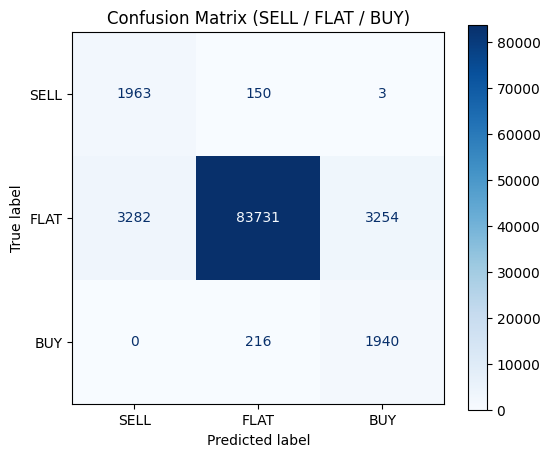

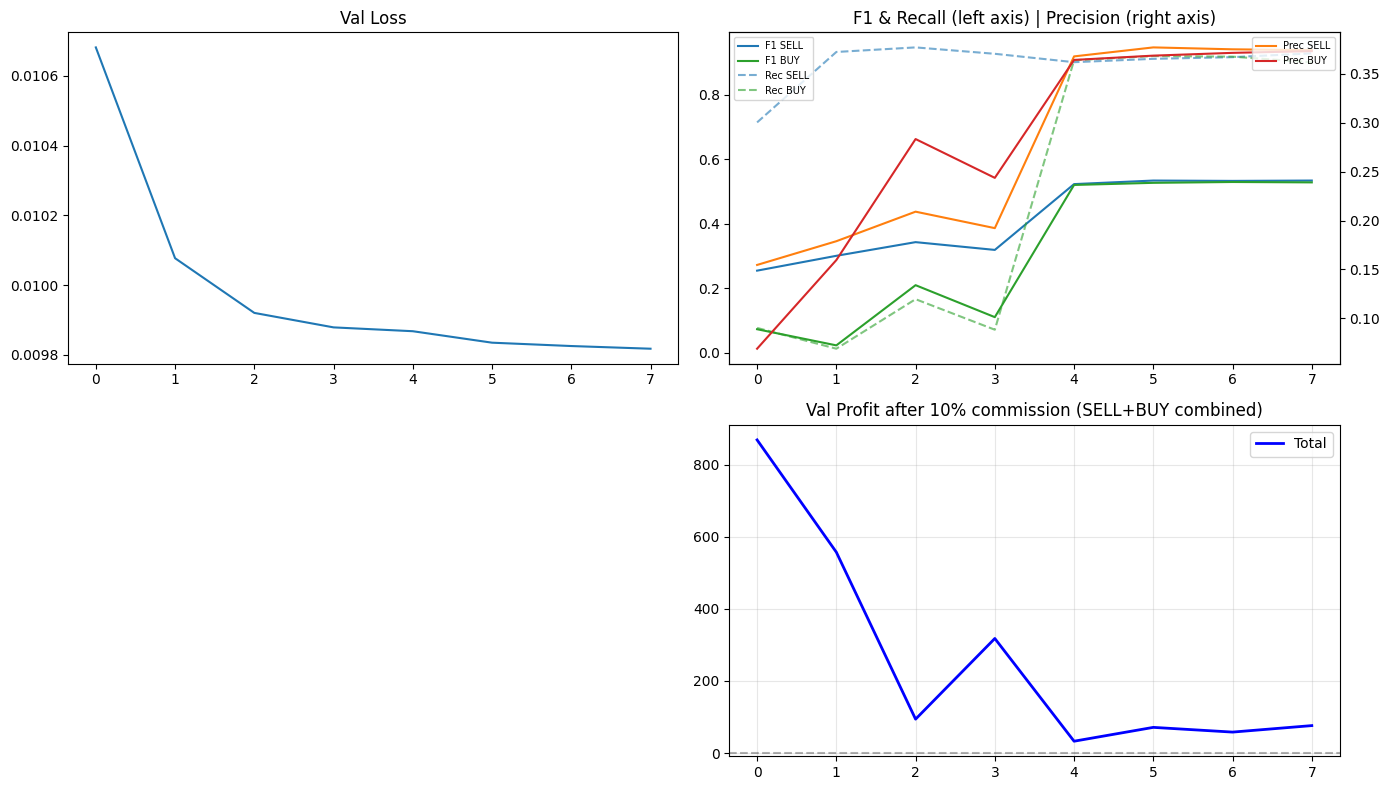

Epoch 8:   0%|          | 7/1665 [00:02<10:35,  2.61it/s]


KeyboardInterrupt: 

In [15]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from IPython.display import clear_output

use_amp = device.type == 'cuda'
torch.backends.cuda.matmul.allow_tf32 = True
scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)

warmup_steps = 200
total_steps  = len(train_loader) * NUM_EPOCHS

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_losses, val_losses_all = [], []
f1_sell,   prec_sell,   rec_sell   = [], [], []
f1_buy,    prec_buy,    rec_buy    = [], [], []
pnl = []

for epoch in range(NUM_EPOCHS):

    # --- Train ---
    model.train()
    train_loss = 0.0
    for xb, yb, outcome_b in tqdm(train_loader, desc=f"Epoch {epoch}"):
        xb, yb = xb.to(device), yb.to(device)
        outcome_b = outcome_b.to(device) if isinstance(outcome_b, torch.Tensor) else outcome_b
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            loss = criterion(model(xb), yb, outcome_b)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))

    # --- Validate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_outcomes = [], [], []
    with torch.no_grad():
        for xb, yb, outcome_b in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outcome_b = outcome_b.to(device) if isinstance(outcome_b, torch.Tensor) else outcome_b
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits   = model(xb)
                val_loss += criterion(logits, yb, outcome_b).item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())
            all_outcomes.extend(
                outcome_b.cpu().numpy() if isinstance(outcome_b, torch.Tensor) else outcome_b)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    # --- Metrics ---
    all_preds_np    = np.array(all_preds)
    all_outcomes_np = np.array(all_outcomes)   # (N, 2)
    sell_mask = (all_preds_np == 0)
    buy_mask  = (all_preds_np == 2)

    # P&L: apply commission and sum over predicted trade bars
    sell_net    = all_outcomes_np[:, 0] - COMMISSION * np.abs(all_outcomes_np[:, 0])
    buy_net     = all_outcomes_np[:, 1] - COMMISSION * np.abs(all_outcomes_np[:, 1])
    profit_sell = float(sell_net[sell_mask].sum()) if sell_mask.any() else 0.0
    profit_buy  = float(buy_net[buy_mask].sum())   if buy_mask.any()  else 0.0
    profit      = profit_sell + profit_buy

    val_loss_value = val_loss / total
    acc = accuracy_score(all_targets, all_preds)

    # Per-class precision/recall/F1 — average=None returns one value per class [SELL, FLAT, BUY]
    p_per, r_per, f_per, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=[0, 1, 2], average=None, zero_division=0)
    f1s, ps, rs = f_per[0], p_per[0], r_per[0]   # SELL (class 0)
    f1b, pb, rb = f_per[2], p_per[2], r_per[2]   # BUY  (class 2)

    val_losses_all.append(val_loss_value)
    f1_sell.append(f1s);  prec_sell.append(ps);  rec_sell.append(rs)
    f1_buy.append(f1b);   prec_buy.append(pb);   rec_buy.append(rb)
    pnl.append(profit)

    # --- Plot ---
    clear_output(wait=True)
    print(f"Epoch {epoch} | Acc: {acc:.4f} | "
          f"Profit (after {COMMISSION:.0%} commission): {profit:.0f} "
          f"[SELL: {profit_sell:.0f}  BUY: {profit_buy:.0f}] | "
          f"Val Loss: {val_loss_value:.6f}\n")
    print(classification_report(all_targets, all_preds,
                                 target_names=['SELL', 'FLAT', 'BUY'], zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(all_targets, all_preds),
                           display_labels=['SELL', 'FLAT', 'BUY']).plot(
        cmap='Blues', values_format='d', ax=ax)
    ax.set_title('Confusion Matrix (SELL / FLAT / BUY)')
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(val_losses_all)
    axes[0, 0].set_title('Val Loss')

    axes[0, 1].plot(f1_sell,  label='F1 SELL',   color='tab:blue')
    axes[0, 1].plot(f1_buy,   label='F1 BUY',    color='tab:green')
    axes[0, 1].plot(rec_sell, label='Rec SELL',  color='tab:blue',  linestyle='--', alpha=0.6)
    axes[0, 1].plot(rec_buy,  label='Rec BUY',   color='tab:green', linestyle='--', alpha=0.6)
    ax2 = axes[0, 1].twinx()
    ax2.plot(prec_sell, label='Prec SELL', color='tab:orange')
    ax2.plot(prec_buy,  label='Prec BUY',  color='tab:red')
    axes[0, 1].set_title('F1 & Recall (left axis) | Precision (right axis)')
    axes[0, 1].legend(loc='upper left', fontsize=7)
    ax2.legend(loc='upper right', fontsize=7)

    axes[1, 0].axis('off')

    axes[1, 1].plot(pnl, color='blue', linewidth=2, label='Total')
    axes[1, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[1, 1].set_title(f'Val Profit after {COMMISSION:.0%} commission (SELL+BUY combined)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


## Save Model Pack

Saves the full model pack (weights, params, scaler, features, preprocessing functions)
to `Engine/Model Packs/`.  A single multiclass pack replaces the paired BUY+SELL packs
used by the binary workflow.

In [16]:
import pickle
import inspect

today      = pd.Timestamp.now().strftime('%Y%m%d')
ds_title   = DS_NAME.split('/')[-1].split('.')[0]
model_name = '_'.join([ds_title, MODEL_TYPE, str(SEQ_LEN) + 'seq', today, MODEL_VERSION])

model_info = {
    'dataset_name':  ds_title,
    'dataset_dir':   DS_NAME,
    'date_trained':  today,
    'model_type':    MODEL_TYPE,
    'task':          'multiclass',
    'class_map':     {0: 'SELL', 1: 'FLAT', 2: 'BUY'},
    'seq_len':       SEQ_LEN,
    'class_weights': weights.tolist(),
    'n_epochs':      NUM_EPOCHS,
}

loss_params_serializable = {**loss_params, 'alpha': loss_params['alpha'].cpu().tolist()}

with open(f'../Engine/Model Packs/{model_name}_model.pkl', 'wb') as f:
    pickle.dump({
        # Model
        'model':              model.state_dict(),
        'model_class':        LSTMAttentionSEClassifier,
        'model_class_source': inspect.getsource(LSTMAttentionSEClassifier),
        'model_params':       model_params,
        'model_info':         model_info,

        # Features & Preprocessing
        'features':                   features,
        'feature_count':              X_train.shape[1],
        'feature_function':           add_selected_features,
        'feature_function_source':    inspect.getsource(add_selected_features),
        'preprocess_function':        preprocess_ohlcv,
        'preprocess_function_source': inspect.getsource(preprocess_ohlcv),
        'preprocess_args':            preprocess_ohlcv_args,
        'scaler':                     scaler,

        # Labeling & Outcomes
        'label_function':          causal_triple_barrier_hilow_trend_labeler,
        'label_function_source':   inspect.getsource(causal_triple_barrier_hilow_trend_labeler),
        'label_params':            label_params,
        'regime_params':           regime_params,
        'outcome_params':          outcome_params,
        'rollover_window':         ROLLOVER_WINDOW,

        # Training Config
        'input_shape':   (SEQ_LEN, X_train.shape[1]),
        'loss_params':   loss_params_serializable,
        'loss_function': TradeProfitabilityLoss,
        'loss_function_source': inspect.getsource(TradeProfitabilityLoss),
        'data_split': {
            'test_start_date': TEST_START,
            'train_rows':      len(X_train),
            'val_rows':        len(X_test),
            'holdout_size':    HOLDOUT_SIZE,
        },
        'torch_version': torch.__version__,

        # Validation Metrics
        'val_metrics': {
            'final_f1_sell':        f1_sell[-1],   'final_f1_buy':        f1_buy[-1],
            'final_precision_sell': prec_sell[-1], 'final_precision_buy': prec_buy[-1],
            'final_recall_sell':    rec_sell[-1],  'final_recall_buy':    rec_buy[-1],
            'final_profit':         pnl[-1],
            'best_f1_sell':         max(f1_sell),  'best_f1_buy':         max(f1_buy),
            'best_precision_sell':  max(prec_sell),'best_precision_buy':  max(prec_buy),
            'f1_sell_curve':        f1_sell,        'f1_buy_curve':        f1_buy,
            'precision_sell_curve': prec_sell,      'precision_buy_curve': prec_buy,
            'recall_sell_curve':    rec_sell,        'recall_buy_curve':   rec_buy,
            'pnl_curve':            pnl,
        },
    }, f)

print('Saved', model_name)

Saved US500_1minute_LSTM_Multiclass_256seq_20260309_v1
